# Kazakhstan–European Union Agricultural Trade Analysis (2018–2024)

## Motivation

Following major disruptions to global agricultural markets during the early 2020s, Kazakhstan attracted increased attention as a potential supplier of agricultural commodities to European markets. Understanding how Kazakhstan's agricultural exports to the European Union evolved over time is relevant for evaluating trade diversification, commodity specialization, and the relationship between domestic agricultural production and export performance.

This project applies a reproducible data analysis workflow to investigate Kazakhstan's agricultural trade with the European Union between 2018 and 2024 using official FAOSTAT data.

---

## Research Question

This study aims to answer the following questions:

1. How did Kazakhstan's agricultural exports to European Union member states evolve between 2018 and 2024?
2. Which agricultural commodities contributed most to export performance?
3. Which European Union countries represented Kazakhstan's principal destination markets?
4. To what extent were changes in export performance associated with changes in Kazakhstan's domestic agricultural production?

The analysis is descriptive and focuses on identifying observable trade patterns rather than establishing causal relationships.

---

## Data Sources

Two official datasets were obtained from the Food and Agriculture Organization of the United Nations (FAOSTAT):

- **Detailed Trade Matrix** – bilateral agricultural trade between Kazakhstan and European Union member states.
- **Production Crops and Livestock** – domestic agricultural production indicators for Kazakhstan.

The original datasets were downloaded as CSV files and processed using Python before being transformed into analysis-ready Parquet files.

---

## Study Scope

To maintain a focused and reproducible analysis, the study is limited to:

- **Reporter country:** Kazakhstan
- **Partner countries:** European Union member states represented in the dataset
- **Time period:** 2018–2024
- **Selected agricultural commodities:**
  - Wheat
  - Barley
  - Linseed
  - Sunflower seed
  - Sunflower-seed oil, crude
  - Rapeseed or canola oil, crude
  - Lentils, dry
  - Peas, dry
  - Maize (corn)

The workflow consisted of:

1. Data cleaning and validation using **Pandas**
2. SQL-based exploratory and analytical queries using **DuckDB**
3. Statistical summaries and visualizations using **Python**
4. Interpretation of trade and production patterns based on the processed datasets

---

## Repository Workflow

```
Raw FAOSTAT CSV
        │
        ▼
Data Cleaning (Pandas)
        │
        ▼
Prepared Parquet Files
        │
        ▼
SQL Analysis (DuckDB)
        │
        ▼
Pandas Analysis
        │
        ▼
Visualisations & Findings
```

In [1]:
import pandas as pd

trade = pd.read_parquet("../data/processed/prepared_trade_data.parquet")
production = pd.read_parquet("../data/processed/prepared_production_data.parquet")

In [2]:
trade.head()
trade.info()
production.head()
production.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   reporter_countries  257 non-null    object 
 1   partner_countries   257 non-null    object 
 2   item                257 non-null    object 
 3   year                257 non-null    Int64  
 4   export_quantity     257 non-null    float64
 5   export_value        257 non-null    float64
dtypes: Int64(1), float64(2), object(3)
memory usage: 12.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item            61 non-null     object 
 1   year            61 non-null     Int64  
 2   area_harvested  49 non-null     float64
 3   production      61 non-null     float64
 4   yield           49 non-null     float64
dtypes: Int64(1), float6

In [3]:
# Annual trade development

annual_trade = (
    trade
    .groupby("year", as_index=False)
    .agg(
        total_export_quantity = ("export_quantity", "sum"),
        total_export_value = ("export_value", "sum"),
    )   
)

annual_trade

,year,total_export_quantity,total_export_value
0,2018,810049.80,204130.0
1,2019,585788.79,182377.0
2,2020,369449.72,142654.0
3,2021,434349.14,230960.0
4,2022,523683.78,301022.0
5,2023,756888.78,278495.0
6,2024,463771.22,176194.0


In [4]:
# Commodity composition of trade

commodity_summary = (
    trade
    .groupby("item", as_index=False)
    .agg(
        total_export_quantity = ("export_quantity", "sum"),
        total_export_value = ("export_value", "sum")
    )
    .sort_values("total_export_value", ascending=False)
)

commodity_summary["export_value_share"] = (
    commodity_summary["total_export_value"]
    / commodity_summary["total_export_value"].sum()
    * 100
).round(2)

commodity_summary

,item,total_export_quantity,total_export_value,export_value_share
2,Linseed,1637028.36,832774.0,54.94
8,Wheat,2209915.93,639177.0,42.17
4,"Peas, dry",57454.75,11896.0,0.78
1,"Lentils, dry",13388.59,10433.0,0.69
7,"Sunflower-seed oil, crude",8670.57,9650.0,0.64
6,Sunflower seed,6469.94,5450.0,0.36
5,"Rapeseed or canola oil, crude",3279.16,5228.0,0.34
0,Barley,7773.92,1224.0,0.08
3,Maize (corn),0.01,0.0,0.00


In [5]:
# Destination markets

partners_summary = (
    trade
    .groupby("partner_countries", as_index=False)
    .agg(
        total_export_quantity = ("export_quantity", "sum"),
        total_export_value = ("export_value", "sum")
    )
    .sort_values("total_export_value", ascending=False)
)

partners_summary["export_value_share"] = (
    partners_summary["total_export_value"]
    / partners_summary["total_export_value"].sum()
    * 100
).round(2)

partners_summary

,partner_countries,total_export_quantity,total_export_value,export_value_share
1,Belgium,1063848.58,533176.0,35.17
11,Italy,1851358.06,527895.0,34.83
16,Poland,426228.69,208710.0,13.77
8,Germany,124141.04,63464.0,4.19
12,Latvia,122450.19,54493.0,3.59
3,Czechia,38489.08,27402.0,1.81
21,Spain,109571.71,25348.0,1.67
22,Sweden,56604.60,19173.0,1.26
15,Netherlands (Kingdom of the),38186.60,18017.0,1.19
9,Greece,59665.07,12769.0,0.84


In [6]:
# Production summary

production_summary = (
    production
    .groupby("item", as_index=False)
    .agg(
        average_production = ("production", "mean"),
        average_area = ("area_harvested", "mean"),
        average_yield = ("yield", "mean"),
    )
)

production_summary

,item,average_production,average_area,average_yield
0,Barley,3.366887e+06,2.467899e+06,1366.428571
1,"Lentils, dry",1.757573e+05,1.784411e+05,911.228571
2,Linseed,8.202174e+05,1.139300e+06,718.357143
3,Maize (corn),1.019711e+06,1.713813e+05,5942.028571
4,"Peas, dry",1.326108e+05,1.117194e+05,1187.257143
5,"Rapeseed or canola oil, crude",5.399867e+04,NaN,NaN
6,Sunflower seed,1.133944e+06,9.755519e+05,1143.285714
7,"Sunflower-seed oil, crude",3.926192e+05,NaN,NaN
8,Wheat,1.407999e+07,1.235918e+07,1138.542857


In [7]:
# Aggregate trade by commodity and year

trade_yearly = (
    trade
    .groupby(["year", "item"], as_index=False)
    .agg(
        eu_export_quantity = ("export_quantity", "sum"),
        eu_export_value = ("export_value", "sum")
    )
)

# Merge with production data

analysis = production.merge(trade_yearly, on=["year", "item"], how="left")

analysis.head()

,item,year,area_harvested,production,yield,eu_export_quantity,eu_export_value
0,Barley,2018,2516952.0,3971266.21,1577.8,6223.92,914.0
1,Barley,2019,2976843.0,3830069.25,1286.6,150.00,23.0
2,Barley,2020,2728822.0,3659259.76,1341.0,1400.00,287.0
3,Barley,2021,2157478.0,2366804.99,1097.0,NaN,NaN
4,Barley,2022,2187297.0,3287240.48,1502.9,0.00,0.0


In [8]:
analysis["export_share_of_production"] = (
    analysis["eu_export_quantity"] / analysis["production"] * 100
)

analysis["export_share_of_production"] = (analysis["export_share_of_production"].round(2))

analysis.head()

,item,year,area_harvested,production,yield,eu_export_quantity,eu_export_value,export_share_of_production
0,Barley,2018,2516952.0,3971266.21,1577.8,6223.92,914.0,0.16
1,Barley,2019,2976843.0,3830069.25,1286.6,150.00,23.0,0.00
2,Barley,2020,2728822.0,3659259.76,1341.0,1400.00,287.0,0.04
3,Barley,2021,2157478.0,2366804.99,1097.0,NaN,NaN,NaN
4,Barley,2022,2187297.0,3287240.48,1502.9,0.00,0.0,0.00


In [9]:
import matplotlib.pyplot as plt

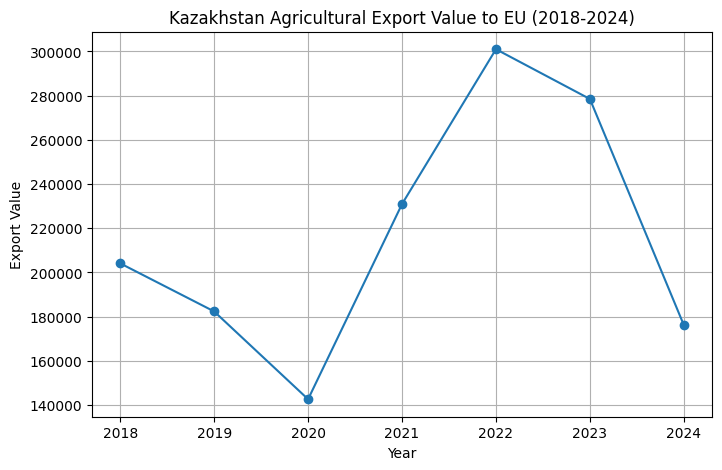

In [10]:
plt.figure(figsize= (8, 5))

plt.plot(
    annual_trade["year"],
    annual_trade["total_export_value"],
    marker = "o",
)

plt.title("Kazakhstan Agricultural Export Value to EU (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Export Value")

plt.grid(True)
plt.show()

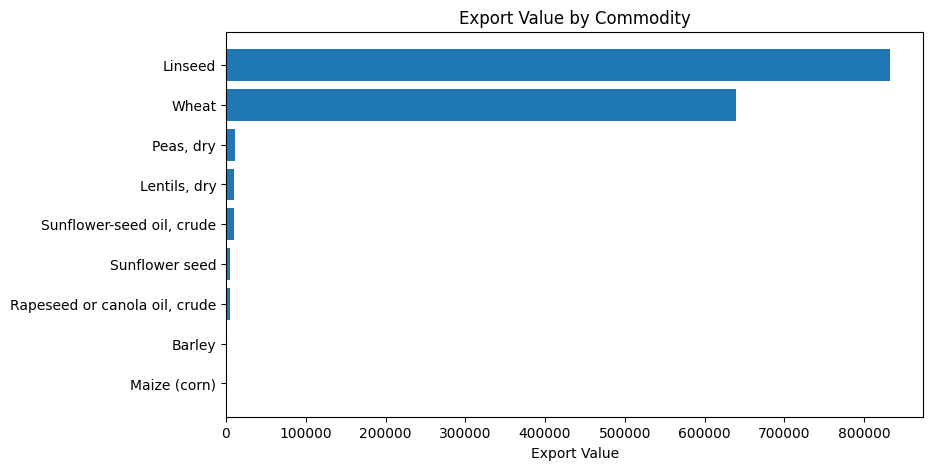

In [11]:
plt.figure(figsize=(9, 5))

plt.barh(
    commodity_summary["item"],
    commodity_summary["total_export_value"]
)

plt.title("Export Value by Commodity")
plt.xlabel("Export Value")
plt.gca().invert_yaxis()  # Invert y-axis to have the highest value on top
plt.show()

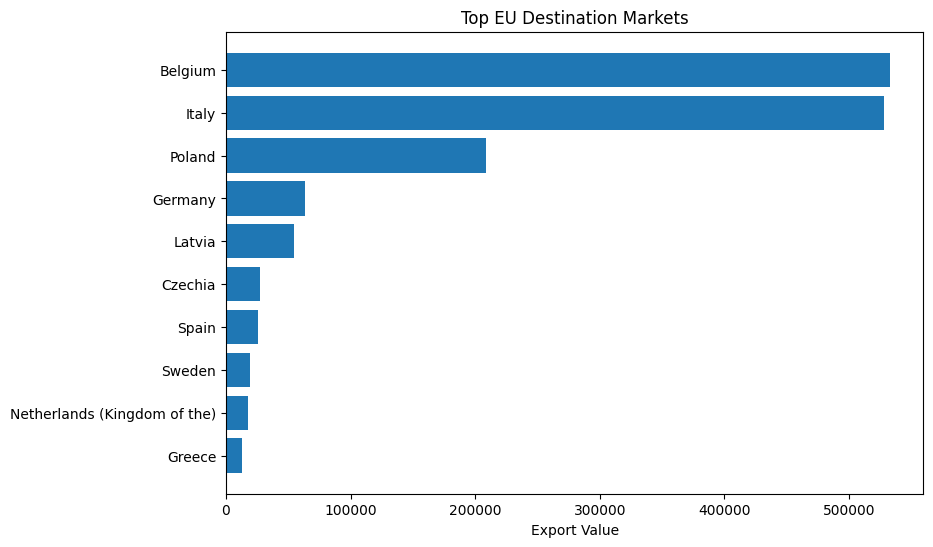

In [12]:
top10 = partners_summary.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top10["partner_countries"],
    top10["total_export_value"]
)

plt.title("Top EU Destination Markets")
plt.xlabel("Export Value")

plt.gca().invert_yaxis()
plt.show()

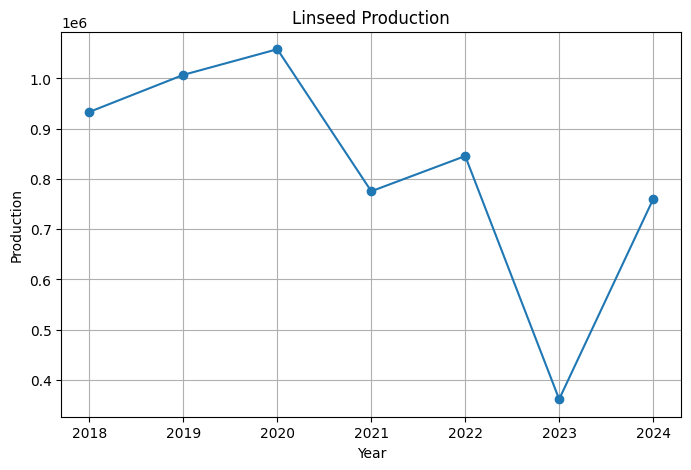

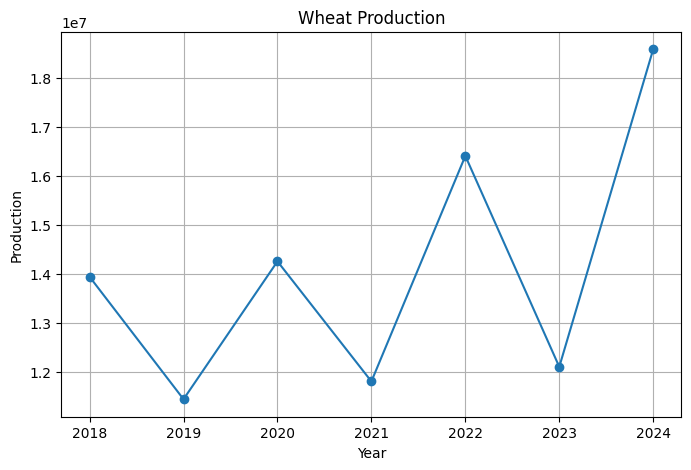

In [13]:
focus = analysis[
    analysis["item"].isin(["Wheat", "Linseed"])]

for commodity in focus["item"].unique():
    plt.figure(figsize=(8, 5))
    subset = focus[focus["item"] == commodity]
    
    plt.plot(
        subset["year"],
        subset["production"],
        marker="o"
    )
    
    plt.title(f"{commodity} Production")
    plt.xlabel("Year")
    plt.ylabel("Production")
    
    plt.grid(True)
    plt.show()

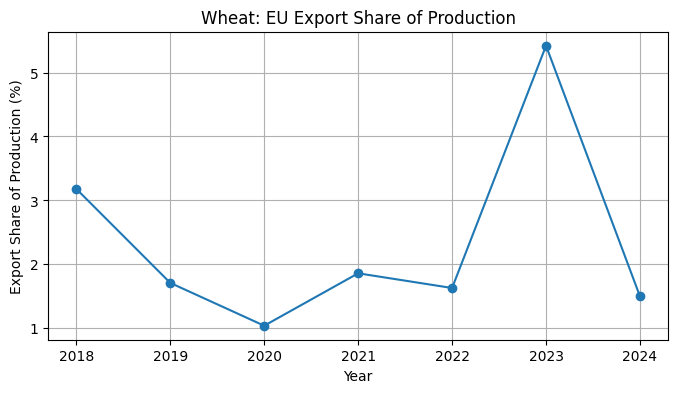

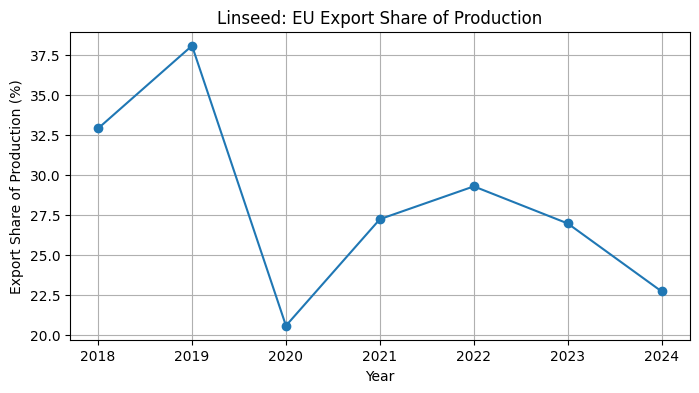

In [14]:
for commodity in ["Wheat", "Linseed"]:
    subset = analysis[analysis["item"] == commodity]
    plt.figure(figsize=(8, 4))

    plt.plot(
        subset["year"],
        subset["export_share_of_production"],
        marker="o"
    )

    plt.title(f"{commodity}: EU Export Share of Production")
    plt.xlabel("Year")
    plt.ylabel("Export Share of Production (%)")

    plt.grid(True)
    plt.show()